In [88]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import json
import pandas as pd

ROOT_FOLDER = Path("../data/raw")

extensions = {".jpg"}

## Data visualisation

In [89]:
TRAIN_FOLDER = ROOT_FOLDER/"train"

n_images_train = sum(1 for file in TRAIN_FOLDER.iterdir()
                     if file.is_file() and file.suffix.lower() in extensions)

print(f"Number of training images : {n_images_train}")

Number of training images : 2630


In [90]:
TEST_FOLDER = ROOT_FOLDER/"test"

n_images_test = sum(1 for file in TEST_FOLDER.iterdir()
                     if file.is_file() and file.suffix.lower() in extensions)

print(f"Number of test images : {n_images_test}")

Number of test images : 531


In [91]:
VAL_FOLDER = ROOT_FOLDER/"val"

n_images_val = sum(1 for file in VAL_FOLDER.iterdir()
                     if file.is_file() and file.suffix.lower() in extensions)

print(f"Number of evalution images : {n_images_val}")

Number of evalution images : 516


In [92]:
list(Path("../data/raw/train").iterdir())[:3]

[PosixPath('../data/raw/train/2050984554.jpg'),
 PosixPath('../data/raw/train/527901046+-1046.jpg'),
 PosixPath('../data/raw/train/2073487737.jpg')]

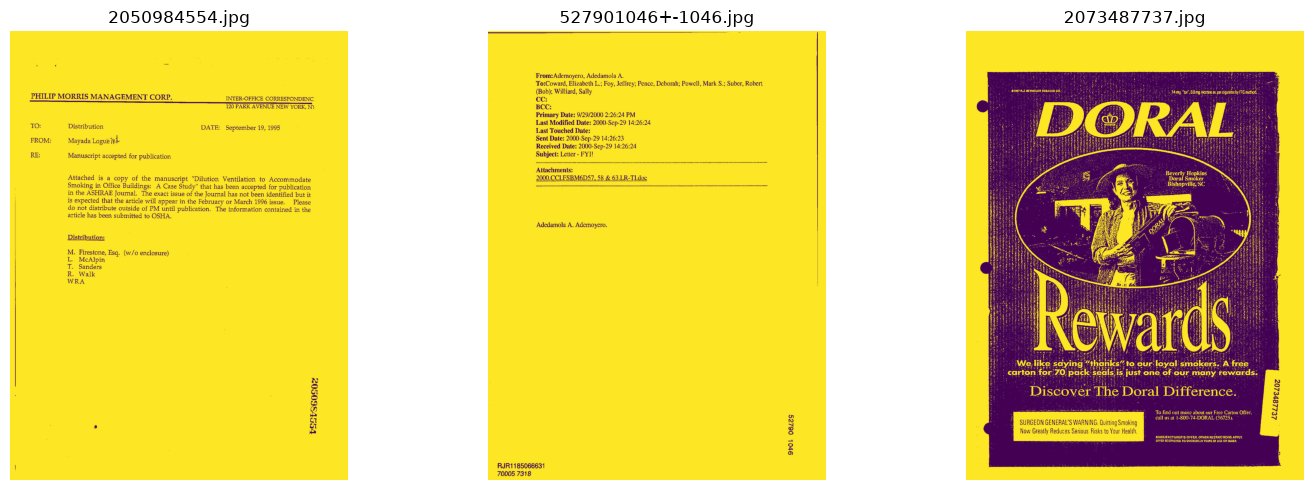

In [93]:
images_train = [
    file for file in TRAIN_FOLDER.rglob("*")
    if file.is_file() and file.suffix.lower() in extensions
][:3]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, image_path in zip(axes, images_train):
    image = Image.open(image_path)
    ax.imshow(image)
    ax.set_title(image_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

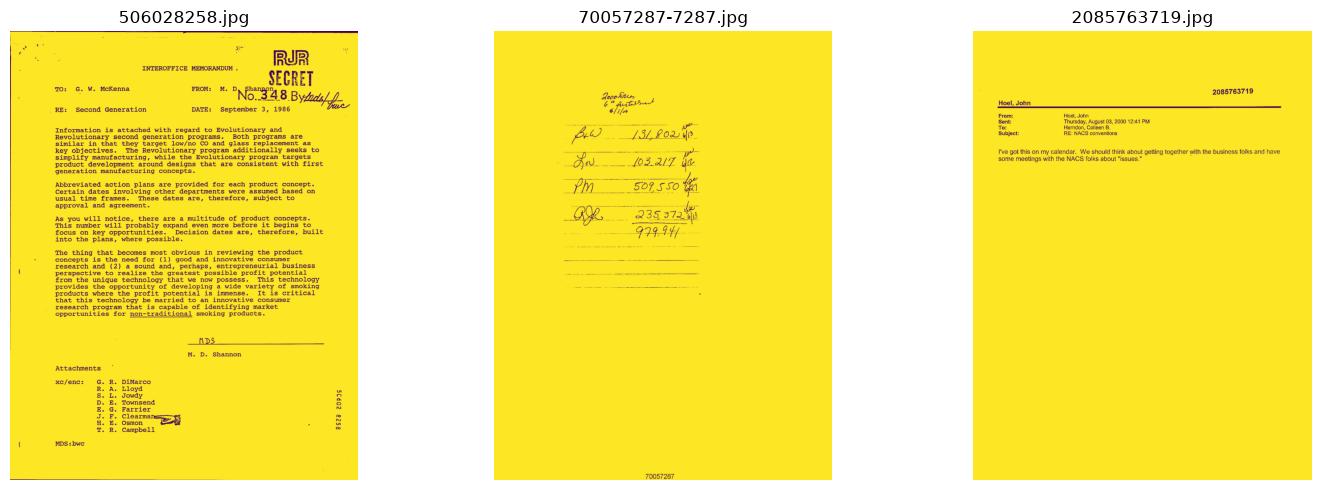

In [94]:
images_test = [
    file for file in TEST_FOLDER.rglob("*")
    if file.is_file() and file.suffix.lower() in extensions
][:3]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, image_path in zip(axes, images_test):
    image = Image.open(image_path)
    ax.imshow(image)
    ax.set_title(image_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

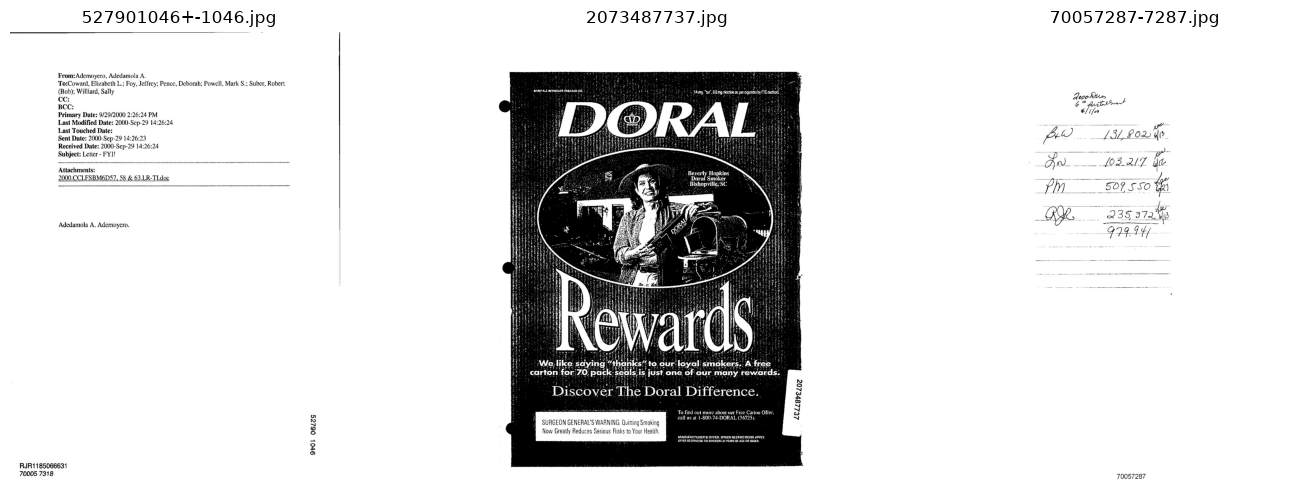

In [95]:
images_val = [
    file for file in VAL_FOLDER.rglob("*")
    if file.is_file() and file.suffix.lower() in extensions
][:3]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, image_path in zip(axes, images_val):
    image = Image.open(image_path)
    ax.imshow(image, cmap="gray")
    ax.set_title(image_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

*Convert images into RGB to 3 before inject in encodeurs.*

In [96]:
df_train = pd.read_json(TRAIN_FOLDER/"metadata.jsonl", lines = True)
df_train.head(3)

,file_name,label,label_id,text
0,12963987.jpg,Note,6,Shue. 135 io a te 4656861 44 465686144 PRODUCE...
1,503999149+-9150.jpg,Report,1,SAMPLING/FIELD MARKETING OPERATIONS WEEKLY STA...
2,2054647558.jpg,Form,8,Xe PHILIP MORRIS USA RECORDS RETENTION SCHEDUL...


In [97]:
df_train["label"].unique()

<StringArray>
[      'Note',     'Report',       'Form',       'ADVE',       'Memo',
      'Email',       'News',     'Letter',     'Resume', 'Scientific']
Length: 10, dtype: str

In [98]:
df_train["label"].value_counts()

label
Email         452
Memo          376
Letter        304
Form          249
Report        200
ADVE          157
News          148
Note          132
Resume         96
Scientific     72
Name: count, dtype: int64

In [99]:
df_test = pd.read_json(TEST_FOLDER/"metadata.jsonl", lines = True)
df_test.head(3)

,file_name,label,label_id,text
0,0000940821.jpg,News,5,"By William Safire WASHINGTON, May 15—Carmine D..."
1,2016003493.jpg,News,5,"HUDSON, MASS. SUN — D. 8,720: — BOSTON METROPO..."
2,2046593592.jpg,News,5,"-19- APR 1 9 196 b THE NEW YORK TIMES, WEDNESD..."


In [100]:
df_test["label"].unique()

<StringArray>
[      'News',       'ADVE',     'Resume',       'Form',     'Letter',
       'Note',       'Memo',     'Report',      'Email', 'Scientific']
Length: 10, dtype: str

In [101]:
df_test["label"].value_counts()

label
Email         57
Memo          48
Letter        38
Form          32
Report        26
ADVE          20
News          19
Note          17
Resume        13
Scientific     9
Name: count, dtype: int64

In [102]:
df_val = pd.read_json(VAL_FOLDER/"metadata.jsonl", lines = True)
df_val.head(3)

,file_name,label,label_id,text
0,2083780285.jpg,News,5,uI-099 {re POT FON) QU LAC GRC (e928 Se soe. (...
1,2025028981-e.jpg,News,5,"Tobacco News, a publication of the Tobacco ins..."
2,2026167362.jpg,News,5,a v 3. ADVERTISING / By Aux M. Fearoman. ‘De-N...


In [103]:
df_val["label"].unique()

<StringArray>
[      'News',     'Letter',       'ADVE',       'Memo',      'Email',
       'Form',     'Report',     'Resume',       'Note', 'Scientific']
Length: 10, dtype: str

In [104]:
df_val["label"].value_counts()

label
Email         56
Memo          47
Letter        38
Form          31
Report        25
ADVE          20
News          18
Note          16
Resume        12
Scientific     9
Name: count, dtype: int64

## Visualize number of duplicate images and verify label

In [105]:
from collections import defaultdict
import hashlib

In [106]:
folders = {"train" : TRAIN_FOLDER, "test" : TEST_FOLDER, "val" : VAL_FOLDER}

def footprint(path, block = 1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for piece in iter(lambda: f.read(block), b""):
            h.update(piece)
    return h.hexdigest()

# List of all images
lignes = []
for name, folder in folders.items():
    for f in folder.rglob("*"):
        if f.suffix.lower() in {".jpg"} :
            lignes.append({"folder" : name, "file": f.name, "path" : str(f), "hash" : footprint(f)})

df_images = pd.DataFrame(lignes)
            
per_image = df_images.groupby("hash").agg(
    nb_occurrences=("path", "count"),
    nb_folders = ("folder", "nunique"),
    folders = ("folder", lambda s : sorted(set(s))),
    file_name = ("file", lambda s : sorted(set(s))),
)

duplicates = per_image[per_image["nb_folders"] > 1].sort_values("nb_folders", ascending = False)
non_duplicates = per_image[per_image["nb_folders"] == 1]
duplicates_in = per_image[per_image["nb_occurrences"] > per_image["nb_folders"]]

print(f"Images found in multiple folders: {len(duplicates)}")
print(duplicates["nb_folders"].value_counts().rename("number of images"))
print(f"Images found in single folder: {len(non_duplicates)}")
print(f"Images duplicated in one folder: {len(duplicates_in)}")

Images found in multiple folders: 940
nb_folders
2    940
Name: number of images, dtype: int64
Images found in single folder: 1797
Images duplicated in one folder: 0


In [107]:
COL_FICHIER = "file_name"
COL_LABEL = "label"

#  Reload the 3 metadata.jsonl
metas = []
for name, folder in folders.items():
    m = pd.read_json(folder / "metadata.jsonl", lines=True)
    m["folder"] = name
    m["file"] = m[COL_FICHIER].map(lambda c: Path(c).name)
    metas.append(m[["folder", "file", COL_LABEL]])
metadata = pd.concat(metas, ignore_index=True)
# Join by file name (in its folder) : each image receives its label
df_lab = df_images.merge(metadata, on=["folder", "file"], how="left", validate="one_to_one")
print(f"Images sans étiquette : {df_lab[COL_LABEL].isna().sum()}")

# Regroup per hash : does the same image always have the same label?
per_hash = df_lab.groupby("hash").agg(
    nb_occurrences=("path", "count"),
    folders=("folder", lambda s: sorted(set(s))),
    names=("file", lambda s: sorted(set(s))),
    labels=(COL_LABEL, lambda s: sorted(set(s.dropna().astype(str)))),
    nb_labels=(COL_LABEL, "nunique"),
)

conflits = per_hash[per_hash["nb_labels"] > 1]
print(f"Images found in multiple folders: {(per_hash['nb_occurrences'] > 1).sum()}")
print(f"With contradictory labels: {len(conflits)}")
conflits

Images sans étiquette : 940
Images found in multiple folders: 940
With contradictory labels: 0


,nb_occurrences,folders,names,labels,nb_labels
hash,,,,,


In [108]:
metadata.shape

(2737, 3)

In [109]:
copies_labeled = df_lab.groupby("hash")["label"].count()

print(copies_labeled.value_counts().sort_index())

label
1    2737
Name: count, dtype: int64


## Data distribution

In [110]:
metadata.head(5)

,folder,file,label
0,train,12963987.jpg,Note
1,train,503999149+-9150.jpg,Report
2,train,2054647558.jpg,Form
3,train,tob10829.35.jpg,Report
4,train,2054124215.jpg,Form


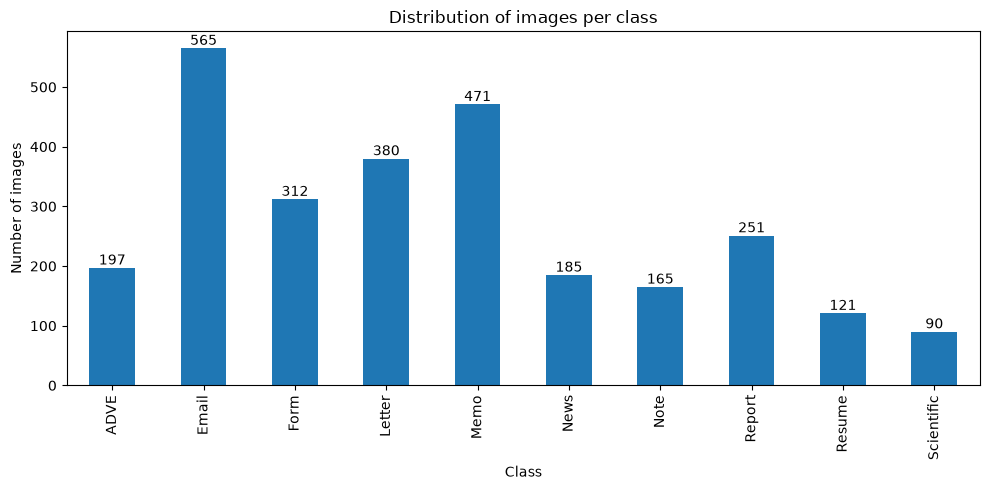

In [111]:
counts = metadata["label"].value_counts().sort_index()

ax = counts.plot(kind = "bar", figsize = (10, 5))
ax.set_xlabel("Class")
ax.set_ylabel("Number of images")
ax.set_title("Distribution of images per class")
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

## Size and quality of images 

In [127]:
def path_of_image(line):
    return Path(folders[line["folder"]]) / line["file"]

In [128]:
def is_legible(ligne):
    try:
        with Image.open(path_of_image(ligne)) as im:
            im.load()   # decodes the entire image
        return True
    except Exception:
        return False

metadata["legible"] = metadata.apply(is_legible, axis=1)
print(f"illegibles Images  : {(~metadata['legible']).sum()}")
metadata[~metadata["legible"]]

illegibles Images  : 0


,folder,file,label,legible


In [129]:
import cv2
import os

In [130]:
import numpy as np

In [131]:
def infos_image(ligne):
    path = path_of_image(ligne)
    try:
        with Image.open(path) as im:
            l, h = im.size
            mode = im.mode
        return pd.Series({"width": l, "height": h, "mode": mode,
                          "size_ko": os.path.getsize(path) / 1024})
    except Exception:
        return pd.Series({"width": np.nan, "height": np.nan, "mode": None, "size_ko": np.nan})

metadata = metadata.join(metadata.apply(infos_image, axis=1))
metadata["ratio"] = metadata["width"] / metadata["height"]

print(metadata["mode"].value_counts())
metadata[["width", "height", "ratio", "size_ko"]].describe()

mode
L    2737
Name: count, dtype: int64


,width,height,ratio,size_ko
count,2737.000000,2737.000000,2737.000000,2737.000000
mean,2061.567775,2688.498721,0.765385,492.916779
std,418.747355,513.206541,0.027711,414.208068
min,1200.000000,1575.000000,0.610687,20.220703
25%,1728.000000,2292.000000,0.753927,212.487305
50%,1728.000000,2292.000000,0.753927,397.144531
75%,2544.000000,3278.000000,0.776699,658.215820
max,3392.000000,4400.000000,1.472840,4959.750000


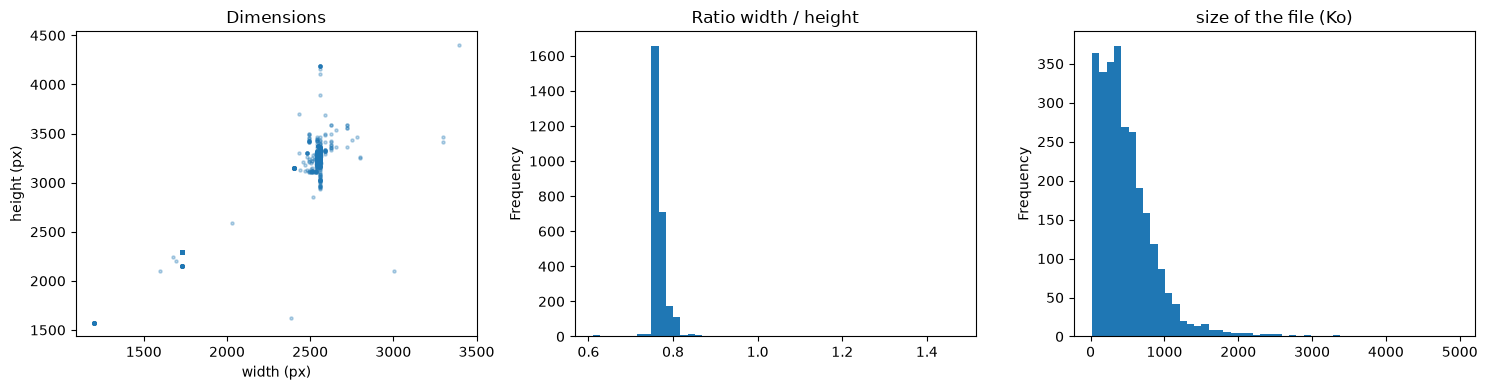

In [132]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(metadata["width"], metadata["height"], alpha=0.3, s=5)
axes[0].set(xlabel="width (px)", ylabel="height (px)", title="Dimensions")
metadata["ratio"].plot(kind="hist", bins=50, ax=axes[1], title="Ratio width / height")
metadata["size_ko"].plot(kind="hist", bins=50, ax=axes[2], title="size of the file (Ko)")
plt.tight_layout()
plt.show()

In [133]:
def quality(ligne):
    img = cv2.imread(str(path_of_image(ligne)), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return pd.Series({"sharpness": np.nan, "brightness": np.nan, "contrast": np.nan})
    return pd.Series({
        "sharpness": cv2.Laplacian(img, cv2.CV_64F).var(),   #  low = blurry
        "brightness": img.mean(),                          # 0 = black, 255 = white
        "contrast": img.std(),
    })

metadata = metadata.join(metadata.apply(quality, axis=1))
metadata[["sharpness", "brightness", "contrast"]].describe()

,sharpness,brightness,contrast
count,2737.000000,2737.000000,2737.000000
mean,6738.631125,238.296782,53.473761
std,7528.133548,21.230707,23.938049
min,323.110366,70.476157,10.821314
25%,2782.745000,235.787352,36.685163
50%,4906.330394,244.011014,50.936472
75%,7961.330961,249.391492,66.341580
max,87212.954710,254.509132,127.275530


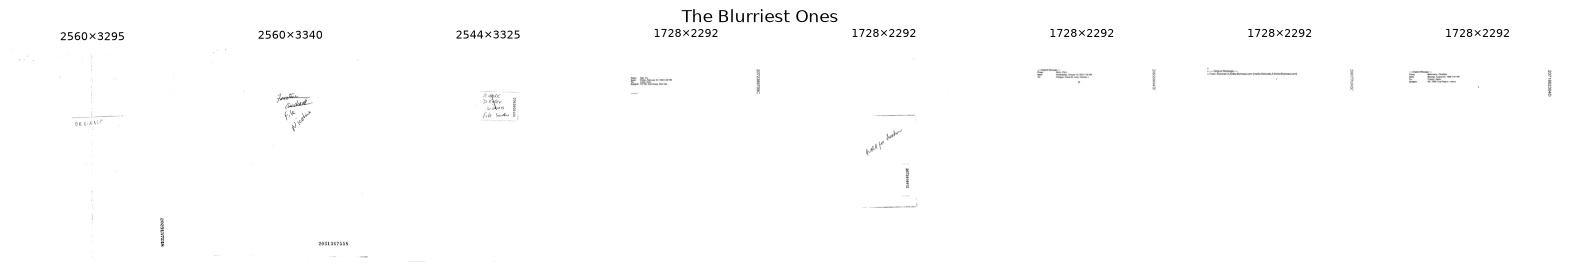

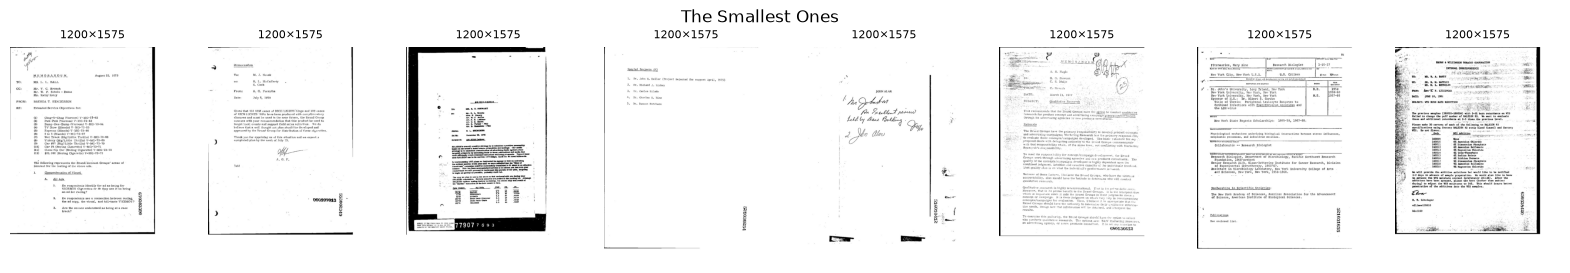

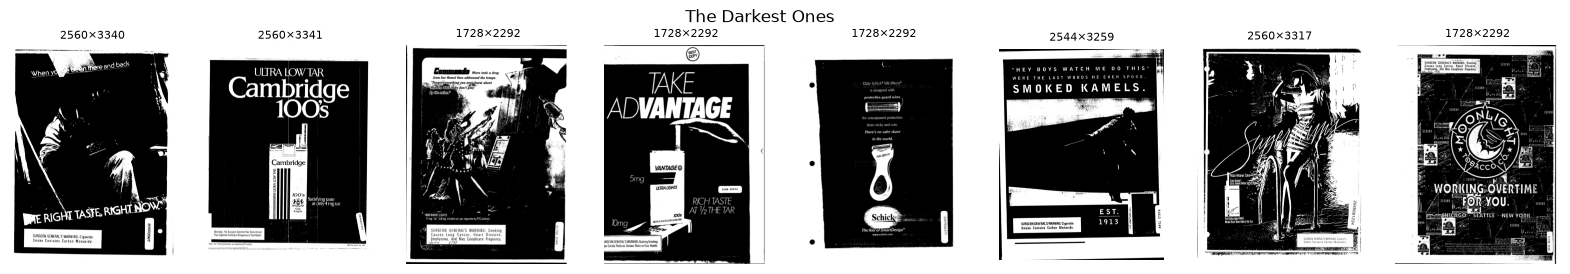

In [138]:
def display(sous_df, title, n=8):
    fig, axes = plt.subplots(1, n, figsize=(2.5 * n, 3))
    for ax, (_, ligne) in zip(axes, sous_df.head(n).iterrows()):
        ax.imshow(Image.open(path_of_image(ligne)), cmap="gray")
        ax.set_title(f"{int(ligne['width'])}×{int(ligne['height'])}", fontsize=8)
        ax.axis("off")
    fig.suptitle(title)
    plt.show()

display(metadata.sort_values("sharpness"), "The Blurriest Ones")
display(metadata.sort_values("width"), "The Smallest Ones")
display(metadata.sort_values("brightness"), "The Darkest Ones")

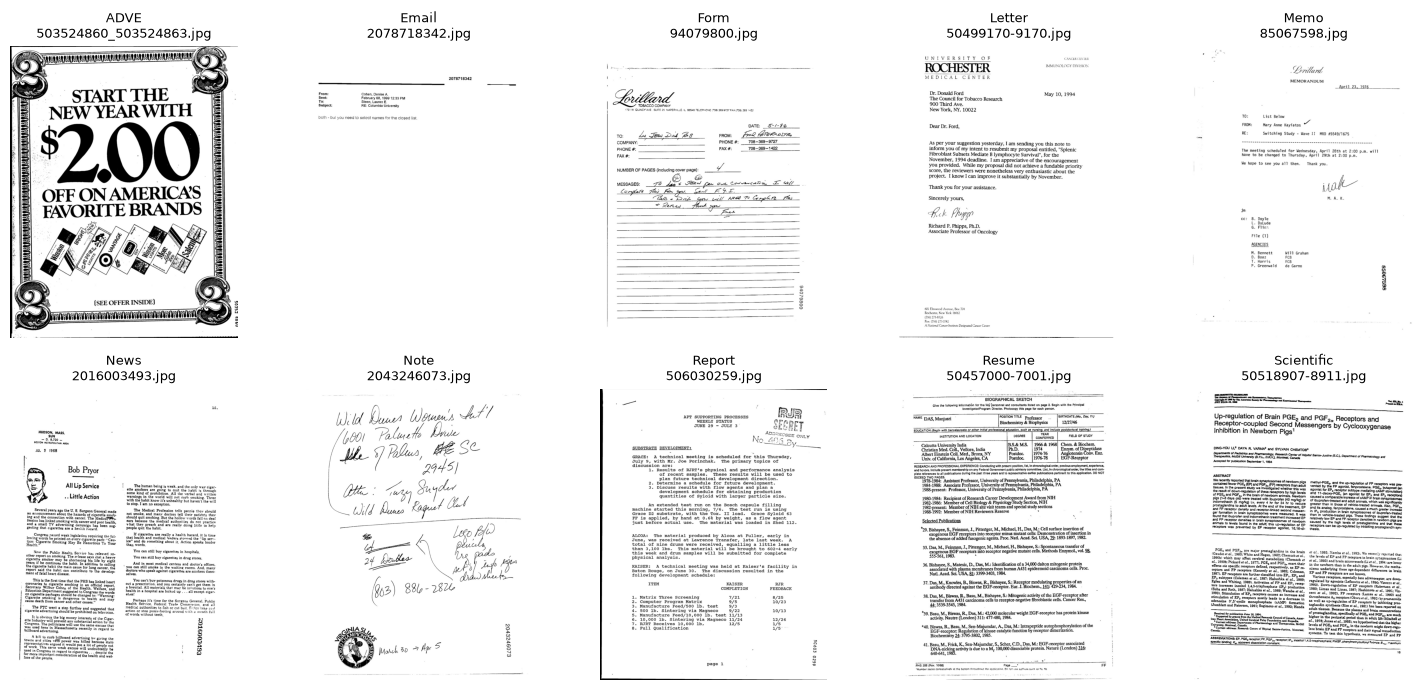

In [139]:
import math

# random line per class

one_per_class = metadata.groupby("label").sample(1).sort_values("label")

n = len(one_per_class)
n_col = 5
n_lig = math.ceil(n / n_col)

fig, axes = plt.subplots(n_lig, n_col, figsize=(3 * n_col, 3.5 * n_lig))
axes = np.atleast_1d(axes).ravel()

for ax, (_, ligne) in zip(axes, one_per_class.iterrows()):
    ax.imshow(Image.open(path_of_image(ligne)), cmap="gray")
    ax.set_title(f"{ligne['label']}\n{ligne['file']}", fontsize=9)
    ax.axis("off")

for ax in axes[n:]:  
    ax.axis("off")

plt.tight_layout()
plt.show()